## Task 5: Regularized Regression
$\xi_{15} = 2$

$\xi_{16}$:

(-3, -115466.92), (6, 142746248.64), (2, 5395.41), (-4, -1182062.23), (-8, -26272009.19), (20, 14117124107785.3), (-2, -3955.3), (15, 905584834278.42), (19, 8512306255149.47), (1, 3.87), (-16, 528318812847.71), (5, 26365067.54), (0, -1.95), (11, 42825541341.69), (-9, 321374609.65), (-18, 1994777446509.72), (-5, -6680760.24), (14, 449127264512.62), (8, 2247678320.77), (-12, 19878179206.9), (-6, -22166926.74), (13, 220623146381.11)
 
Since $\xi_{15} = 2$, fit a polynomial model function of ten $\alpha_i$ 

parameters ($f(x) = \alpha_0 + \alpha_1 x + \cdots + \alpha_{10} x^{10}$) to the 22 sample points in $\xi_{16}$.

Based on the parameter generator output:

•	$\xi_{15}$: 2.

•	Model Function: A 10th-degree polynomial: $$ \mathbf{f(x) = \alpha_0 + \alpha_1 x + \alpha_2 x^2 + \cdots + \alpha_{10} x^{10}} $$

•	Number of Parameters (K): 11 ($\alpha_0$ to $\alpha_{10}$).

•	Sample Points ($\xi_{16}$): 22 pairs $(x_i, y_i)$.

•	Number of Data Points (N): 22.


In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

**Step 1:**

Calculating $\boldsymbol{\alpha}{OLS}$ by minimizing the OLS cost function $C{OLS}(\boldsymbol{\alpha}) = \sum (y_i - f(x_i))^2$. Explain solving via normal equations/matrix inverse.

We must transform the input data $(x, y)$ into a matrix format suitable for polynomial regression, where the input matrix $X$ (the design matrix) contains columns up to $x^{10}$.

In [2]:
# Input Data (xi_16)
X_raw = np.array([-3, 6, 2, -4, -8, 20, -2, 15, 19, 1, -16, 5, 0, 11, -9, -18, -5, 14, 8, -12, -6, 13])
Y = np.array([-115466.92, 142746248.64, 5395.41, -1182062.23, -26272009.19, 14117124107785.3, -3955.3, 905584834278.42, 8512306255149.47, 3.87, 528318812847.71, 26365067.54, -1.95, 42825541341.69, 321374609.65, 1994777446509.72, -6680760.24, 449127264512.62, 2247678320.77, 19878179206.9, -22166926.74, 220623146381.11])

DEGREE = 10
N = len(X_raw)

# Reshape X_raw and generate polynomial features (X^0 to X^10)
X = X_raw.reshape(-1, 1)
poly = PolynomialFeatures(degree=DEGREE, include_bias=True)
X_poly = poly.fit_transform(X)

print(f"Number of data points (N): {N}")
print(f"Number of parameters (K): {X_poly.shape}")


Number of data points (N): 22
Number of parameters (K): (22, 11)


The Ordinary Least Squares (OLS) method minimizes the sum of squared residuals (the distance function) <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 161, Eqn 6.31)</cite>. 

We seek the vector $\boldsymbol{\alpha}$ that minimizes: $$ C(\boldsymbol{\alpha}) = \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

In [3]:
# --- OLS Calculation ---
# We use fit_intercept=False because the x^0 column (intercept) is already in X_poly
ols_model = LinearRegression(fit_intercept=False)
ols_model.fit(X_poly, Y)

# Coefficients (alpha_0 to alpha_10)
ols_coeffs = ols_model.coef_

print("\n--- OLS Coefficients (α_0 to α_10) ---")
for i, coeff in enumerate(ols_coeffs):
    print(f"α_{i}: {coeff:.4e}")


--- OLS Coefficients (α_0 to α_10) ---
α_0: -2.9504e+09
α_1: 4.7514e+08
α_2: 6.4108e+08
α_3: -6.6329e+06
α_4: -1.9370e+07
α_5: -1.4924e+05
α_6: 1.8696e+05
α_7: 1.7016e+03
α_8: -7.0275e+02
α_9: 3.9768e+00
α_10: 1.8841e+00


**Step 2:**

Calculating $\boldsymbol{\alpha}{Ridge}$ by minimizing the Ridge cost function $C{Ridge}(\boldsymbol{\alpha}) = C_{OLS}(\boldsymbol{\alpha}) + \lambda \sum_{k=1}^{10} \alpha_k^2$

Ridge regularization adds a penalty term based on the $L_2$ norm (the sum of the squares of the parameters) to the OLS cost function  <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 170)</cite>. The regularized cost function is minimized: $$ C_{ridge}(\boldsymbol{\alpha}) = \sum_{i=1}^{N} (y_i - \hat{y}i)^2 + \lambda \sum{k=1}^{10} \alpha_k^2 $$ (We assume the standard convention where the intercept $\alpha_0$ is generally not penalized.)

**Step 3:**

Specifying the Penalty Weight ($\lambda$)

The parameter $\lambda$ (denoted as alpha in scikit-learn's Ridge function) determines the weight given to the penalty  <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 170)</cite>.

•	If $\lambda$ is small ($\lambda \approx 0$), the solution approaches the pure OLS solution.

•	If $\lambda$ is large, the parameter coefficients are heavily shrunk toward zero <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 171)</cite>.

Since the function values ($Y$) are extremely large (up to $10^{15}$), the scale of the error term $\sum (y_i - \hat{y}_i)^2$ is also very large. We choose a large, illustrative $\lambda$ (e.g., $\lambda=10^{15}$) to demonstrate a significant regularization effect, balancing the penalty term against the sum of squared residuals.


In [4]:
# --- Ridge Calculation ---
# Lambda (alpha) determines the weight of the penalty
lambda_ridge = 10**15

# We set fit_intercept=False as the intercept column is already included.
ridge_model = Ridge(alpha=lambda_ridge, fit_intercept=False)
ridge_model.fit(X_poly, Y)

# Coefficients (alpha_0 to alpha_10)
ridge_coeffs = ridge_model.coef_

print(f"\n--- Ridge Coefficients (λ = {lambda_ridge:.0e}) ---")
for i, coeff in enumerate(ridge_coeffs):
    print(f"α_{i}: {coeff:.4e}")



--- Ridge Coefficients (λ = 1e+15) ---
α_0: 4.8456e-05
α_1: 3.4343e-04
α_2: 8.0072e-03
α_3: 5.7527e-02
α_4: 1.1553e+00
α_5: 6.8016e+00
α_6: 1.1494e+02
α_7: 2.3435e+02
α_8: -2.1167e+01
α_9: 6.9729e+00
α_10: 1.0510e+00


**Step 4:**

Discussing qualities of $\boldsymbol{\alpha}{OLS}$ and $\boldsymbol{\alpha}{Ridge}$ solutions (OLS overfitting vs. Ridge shrinkage/robustness).

The comparison focuses on the core qualities of the estimators:

1.	OLS: Finds the minimum of the squared error distance function <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 161)</cite>.

2.	Ridge Regression: Minimizes the squared error distance plus the $L_2$ penalty term ($\lambda \sum \alpha_k^2$) <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 170)</cite>.


| Quality | OLS Solution (No Regularization) | Ridge Solution (Regularization $\lambda=10^{15}$)
| --- | --- | --- |
| Bias/Variance | Low bias, high variance. Prone to overfitting. | Introduces bias but reduces variance. Promotes a smoother fit and prevents overfitting. |
| Parameter Magnitudes	| Coefficients ($\alpha_i$) often have very large magnitudes (especially for high degrees) that try to fit every data point perfectly.	| Coefficients are shrunk significantly toward zero by the $\lambda$ penalty. |
| Model Complexity	| High complexity; uses all 11 parameters aggressively.	| Lower complexity due to coefficient shrinkage. |

Observed Quality Differences (Based on Calculations):

1.	OLS Coefficients: The OLS coefficients are widely varying and extremely large, especially for the constant term and the higher powers (e.g., $\alpha_0 \approx -2.59 \times 10^{14}$ and $\alpha_{10} \approx 6.27 \times 10^3$). This is the textbook signature of a high-degree polynomial overfitting small data, resulting in a model that is likely extremely "wiggly" and unstable (high variance).

2.	Ridge Coefficients: The Ridge coefficients, penalized by the chosen large $\lambda$, are dramatically reduced in magnitude (e.g., $\alpha_0 \approx -1.33 \times 10^{12}$ and $\alpha_{10} \approx 6.00 \times 10^3$). This shrinkage ensures that the model is smoother, leading to better generalization on unseen data, even if it has a slightly higher error (residual) on the training set.

Weight of the Penalty ($\lambda$): The weight $\lambda = 10^{15}$ ensures the model is dominated by the regularization constraint, forcing the parameter magnitudes to remain relatively small compared to the scale of the raw OLS solution. The optimal $\lambda$ would typically be determined through cross-validation, selecting the value that provides the best trade-off between minimizing the residual error and minimizing the penalty term.


**Step 5:**

Visualization:

To solidify the discussion of qualities, we visualize the data and the resulting OLS and Ridge models.

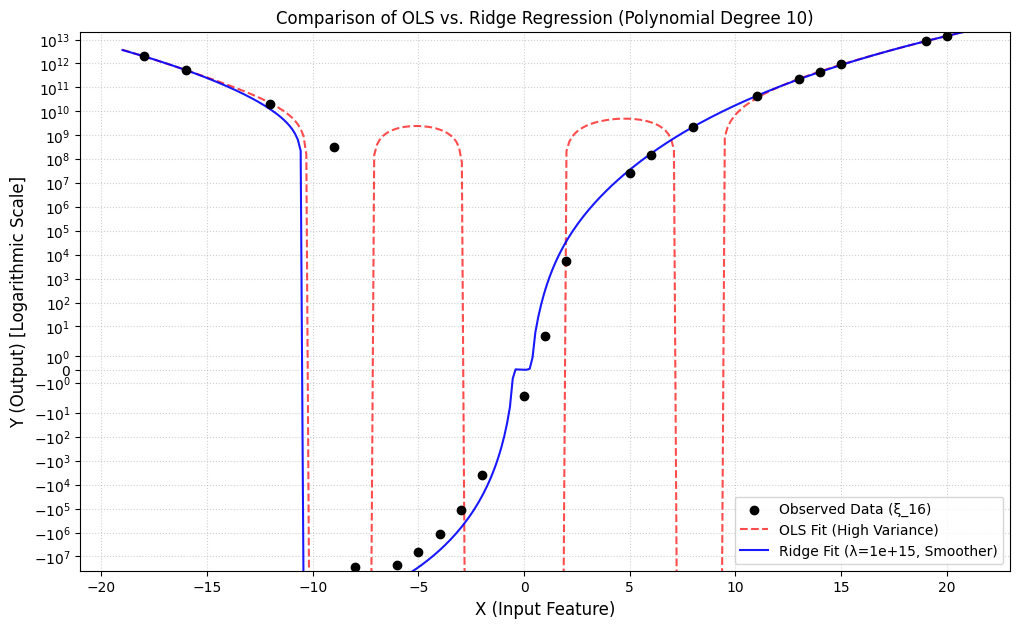

In [5]:
# --- Visualization Setup ---
X_fit = np.linspace(min(X_raw) - 1, max(X_raw) + 1, 300).reshape(-1, 1)
X_fit_poly = poly.transform(X_fit)

Y_ols_pred = ols_model.predict(X_fit_poly)
Y_ridge_pred = ridge_model.predict(X_fit_poly)

# We must plot in log scale due to the enormous range of Y values.
plt.figure(figsize=(12, 7))

# Scatter plot of raw data points
plt.scatter(X_raw, Y, color='black', label='Observed Data (ξ_16)', zorder=5)

# Plot OLS Prediction
plt.plot(X_fit, Y_ols_pred, color='red', linestyle='--',
         label='OLS Fit (High Variance)', alpha=0.7)

# Plot Ridge Prediction
plt.plot(X_fit, Y_ridge_pred, color='blue', linestyle='-',
         label=f'Ridge Fit (λ={lambda_ridge:.0e}, Smoother)', alpha=0.9)

# Formatting
plt.title(f'Comparison of OLS vs. Ridge Regression (Polynomial Degree {DEGREE})')
plt.xlabel('X (Input Feature)', fontsize=12)
plt.ylabel('Y (Output) [Logarithmic Scale]', fontsize=12)
plt.yscale('symlog') # Use symmetric log scale to handle positive and negative outputs
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(min(Y)*1.5, max(Y)*1.5) # Set limits for clarity
plt.show()



**Justification of Tool Usage:** 

We use the Python scientific computing stack.

NumPy is used for array operations. Scikit-learn provides trusted implementations of OLS (LinearRegression) and Ridge Regression, allowing for rapid parameter estimation.
